# K-Nearest Neighbors on Personal Transaction Data

Brianna Sengchan

## Imports & Data Loading

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)

In [2]:
sys.path.insert(0, "../data")

from data_loading import load_train_test_split

X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape)
print("number of features:", len(feature_cols))
print("number of classes:", y_train.nunique())

train: (8644, 72) (8644,)
test:  (2162, 72) (2162,)
number of features: 72
number of classes: 5


## Model Training & Evaluation

In [3]:
X_train

,Transaction Type,Day of Week,Month,Amount_scaled,Desc_Amazon,Desc_Amazon Video,Desc_American Tavern,Desc_BBQ Restaurant,Desc_BP,Desc_Bakery Place,...,Desc_Sushi Restaurant,Desc_Target,Desc_Thai Restaurant,Desc_Tiny Deli,Desc_Valero,Desc_Vietnamese Restaurant,Desc_Wendy's,Acct_Checking,Acct_Platinum Card,Acct_Silver Card
3279,0,1,10,-0.110191,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2882,0,2,3,-0.426278,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3779,0,1,6,-0.199947,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
8962,0,5,3,-0.029880,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
8894,0,5,4,0.355848,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1809,1,0,5,0.348292,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2742,0,3,12,-0.541001,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1467,1,4,3,0.228259,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
9075,0,1,5,-0.541052,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [4]:
# Checking the class distribution for data imbalance

class_distribution = y_train.value_counts()

print("Class distribution in training set:")
print(class_distribution)

print("\nClass distribution percentage:")
print((class_distribution / len(y_train) * 100).round(2))

Class distribution in training set:
Category_Label
0    3056
1    2980
3    1864
2     538
4     206
Name: count, dtype: int64

Class distribution percentage:
Category_Label
0    35.35
1    34.47
3    21.56
2     6.22
4     2.38
Name: count, dtype: float64


### Baseline Model

In [5]:
# KNN model
knn = KNeighborsClassifier(
    n_neighbors = 5,
    weights = "uniform",
    metric = "minkowski",
    p=2
)

start_train = time.time()
knn.fit(X_train, y_train)
baseline_train_time = time.time() - start_train

start_pred = time.time()
baseline_pred = knn.predict(X_test)
baseline_pred_time = time.time() - start_pred

# Print Results
print("Accuracy: ", accuracy_score(y_test, baseline_pred))
print("Weighted F1: ", f1_score(y_test, baseline_pred, average = "weighted", zero_division = 0))
print("Training Time: ", baseline_train_time)
print("Prediction TIme: ", baseline_pred_time)

Accuracy:  0.8677150786308974
Weighted F1:  0.8648108768837949
Training Time:  0.006840229034423828
Prediction TIme:  1.8961765766143799


### Hyperparameter Tuning

In [6]:
param_grid = {
    "n_neighbors": [3, 5, 7, 11],
    "weights": ["uniform", "distance"],
    "p": [1, 2]
}

knn = KNeighborsClassifier(
    metric = "minkowski",
    algorithm = "brute"
)

grid = GridSearchCV(
    estimator = knn,
    param_grid = param_grid,
    scoring = "f1_weighted",
    cv = 2,
    n_jobs = -1,
    verbose = 1
)

start_train = time.time()
grid.fit(X_train, y_train)
tuned_time = time.time() - start_train

# Print Results
print("Best Parameters: ", grid.best_params_)
print("Best Weighted F1: ", grid.best_score_)
print("Tuned Time: ", tuned_time)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Best Parameters:  {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Best Weighted F1:  0.8603534538399399
Tuned Time:  7.872471332550049


### Evaluation

In [7]:
best_knn = grid.best_estimator_

start_pred = time.time()
tuned_pred = best_knn.predict(X_test)
tuned_pred_time = time.time() - start_pred

accuracy = accuracy_score(y_test, tuned_pred)
precision = precision_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
recall = recall_score(y_test, tuned_pred, average = "weighted", zero_division = 0)
f1 = f1_score(y_test, tuned_pred, average = "weighted", zero_division = 0)

print("Best Parameters: ", grid.best_params_)
print("Accuracy: ", accuracy)
print("Weighted Precision: ", precision)
print("Weighted Recall: ", recall)
print("Weighted F1: ", f1)
print("Prediction Time: ", tuned_pred_time)

Best Parameters:  {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}
Accuracy:  0.9241443108233117
Weighted Precision:  0.9261402701997486
Weighted Recall:  0.9241443108233117
Weighted F1:  0.9234682431946012
Prediction Time:  0.08954024314880371


### Classification Report

In [8]:
print("Final Tuned KNN Classification Report")
print("------------------------------------")
print(classification_report(y_test, tuned_pred, zero_division = 0))

Final Tuned KNN Classification Report
------------------------------------
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       764
           1       0.94      0.91      0.92       745
           2       0.98      0.91      0.94       135
           3       0.93      0.89      0.91       466
           4       1.00      0.69      0.82        52

    accuracy                           0.92      2162
   macro avg       0.95      0.88      0.91      2162
weighted avg       0.93      0.92      0.92      2162



### Per-Class Accuracy

In [9]:
# Checking Per-Class Accuracy

labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, tuned_pred, labels = labels)

class_accuracy = cm.diagonal() / cm.sum(axis = 1)

class_accuracy_df = pd.DataFrame({
    "Class": labels,
    "Accuracy": class_accuracy
})

class_accuracy_df

,Class,Accuracy
0,0,0.982984
1,1,0.906040
2,2,0.911111
3,3,0.886266
4,4,0.692308


### Confusion Matrix

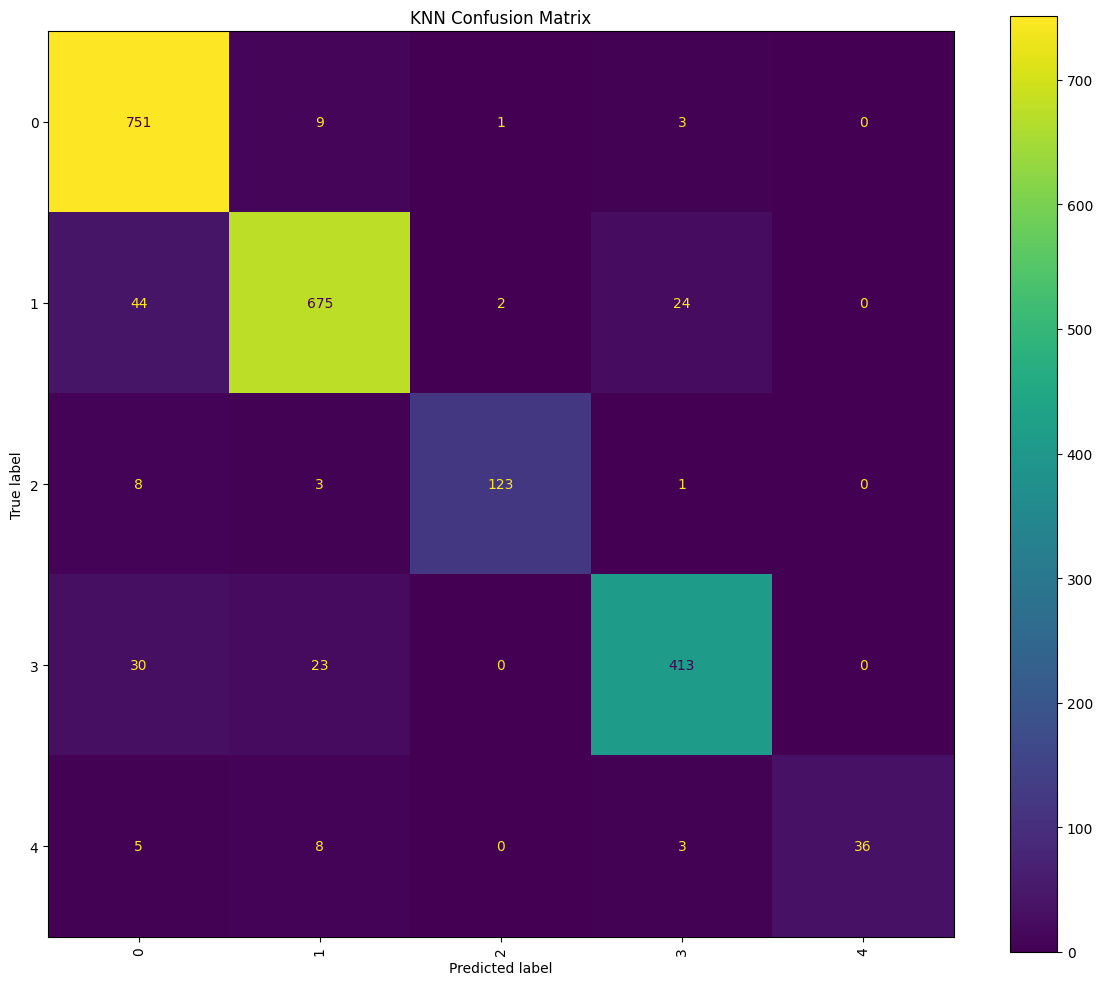

In [10]:
fig, ax = plt.subplots(figsize = (12, 10))

display = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = labels
)

display.plot(
    ax = ax,
    xticks_rotation = 90,
    values_format = "d"
)

plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.show()